<a href="https://colab.research.google.com/github/CienciaDatosUdea/005_CCA_Estudiantes/blob/main/Laboratorios/05_Lab_regresion_y_clasificacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Laboratorio 4 — Regresión lineal y clasificación

## Cómo trabajar

* Las celdas marcadas con ✏️ **Ejercicio** tienen huecos `...` que usted debe completar.
* Después de cada ejercicio hay una celda ✅ **Checkpoint**: si corre sin errores, su implementación es correcta.
* Las demás celdas son de lectura y ejecución: córralas en orden, de arriba hacia abajo.

**Duración estimada:** 3 horas. **Entregable:** este mismo notebook ejecutado + las respuestas de la sección final.

## 0. Preparación

Ejecute esta celda una sola vez.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

rng = np.random.default_rng(42)
print("Listo. numpy", np.__version__)

Listo. numpy 2.2.5


### La receta de 5 pasos

Todo lo que sigue —regresión lineal, multivariada y clasificación— es la **misma receta** con piezas distintas:

| Paso | Qué se elige | Regresión lineal | Regresión logística |
|---|---|---|---|
| 1 | Hipótesis $h_\Theta(X)$ | $\Theta^T X$ | $\sigma(\Theta^T X)$ |
| 2 | Función de coste $J(\Theta)$ | error cuadrático | entropía cruzada |
| 3 | Gradiente $\nabla_\Theta J$ | $\frac{1}{m}X^T(h-y)$ | $\frac{1}{m}X^T(h-y)$ |
| 4 | Optimizador | gradiente descendente / ecuación normal | gradiente descendente |
| 5 | Evaluación | $J$, $R^2$ | exactitud, curvas de aprendizaje |

Fíjese desde ya en la fila 3: **el gradiente tiene exactamente la misma forma en los dos modelos**. Volveremos a esto en la Parte 6.

> *Non-Free-Lunch Theorem*: no existe un algoritmo universalmente mejor. Siempre conviene inyectar conocimiento del problema.

---
# Parte 1 — Una característica: hipótesis y función de coste

Tenemos $m$ pares de entrenamiento $(x^{(1)},y^{(1)}),\dots,(x^{(m)},y^{(m)})$ y proponemos la hipótesis lineal

$$h_\theta(x) = \theta_0 + \theta_1 x$$

La calidad del ajuste se mide con la **función de coste** (métrica euclidiana):

$$J(\theta_0,\theta_1)=\frac{1}{2m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)^2$$

Entrenar = **encontrar el mínimo de $J$**.

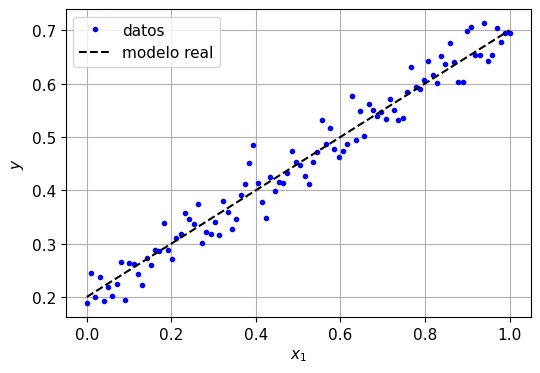

In [3]:
# Datos sintéticos: conocemos la respuesta (theta_0 = 0.2, theta_1 = 0.5)
m = 100
X = np.linspace(0, 1, m)
theta_real = (0.2, 0.5)
y = theta_real[0] + theta_real[1] * X + rng.normal(0, 0.03, m)

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.", label="datos")
plt.plot(X, theta_real[0] + theta_real[1] * X, "k--", label="modelo real")
plt.xlabel("$x_1$"); plt.ylabel("$y$"); plt.legend(); plt.show()

In [4]:
def H(X, t0, t1):
    """Hipótesis lineal h(x) = t0 + t1*x."""
    return t0 + t1 * X


def J(t0, t1, X, y):
    """Función de coste (error cuadrático medio / 2)."""
    return ((H(X, t0, t1) - y) ** 2).mean() / 2


print("J en el óptimo teórico:", round(J(*theta_real, X, y), 6))
print("J en un punto malo   :", round(J(0.0, 3.0, X, y), 6))

J en el óptimo teórico: 0.000427
J en un punto malo   : 0.81604


### ✏️ Ejercicio 1.1 — Barrido de $\theta_1$

Fije $\theta_0 = 0.2$ y evalúe $J$ sobre una malla de valores de $\theta_1$. Complete la línea marcada.

In [6]:
t1_grid = np.linspace(-1, 2, 300)

# TODO: evalúe J(0.2, t1, X, y) para cada t1 de t1_grid
# simplemente evaluamos J para cada valor de t1_grid, al final lo volvemos array  
J_grid = [J(0.2, t1, X, y) for t1 in t1_grid]
J_grid = np.array(J_grid)

# se busca el valor mínimo de theta1, viendo donde J es mínimo
t1_opt = t1_grid[np.argmin(J_grid)]
print("theta_1 que minimiza J:", round(t1_opt, 4))

theta_1 que minimiza J: 0.505


In [7]:
# ✅ Checkpoint 1.1
assert np.shape(J_grid) == (300,), "J_grid debe tener un valor por cada theta_1"
assert abs(t1_opt - theta_real[1]) < 0.05, "el mínimo no coincide con la pendiente real"
print("Correcto ✔")

Correcto ✔


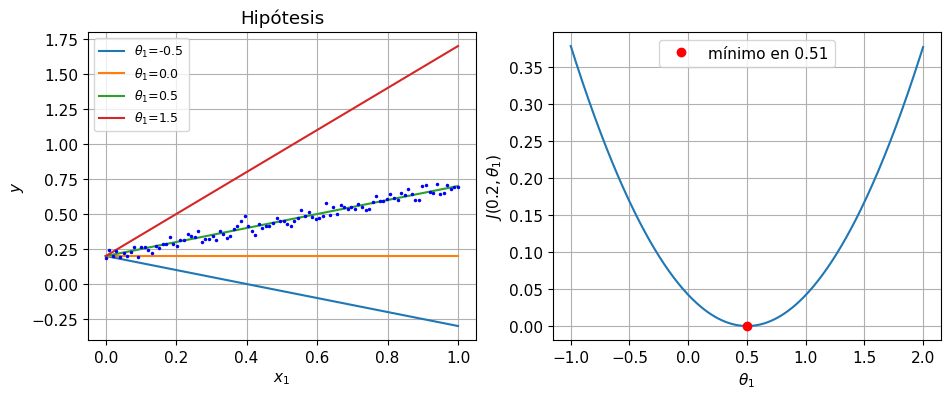

In [8]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
for t1 in [-0.5, 0.0, 0.5, 1.5]:
    plt.plot(X, H(X, 0.2, t1), label=f"$\\theta_1$={t1}")
plt.plot(X, y, "b.", ms=3)
plt.xlabel("$x_1$"); plt.ylabel("$y$"); plt.legend(fontsize=9); plt.title("Hipótesis")

plt.subplot(122)
plt.plot(t1_grid, J_grid)
plt.plot(t1_opt, J_grid.min(), "ro", label=f"mínimo en {t1_opt:.2f}")
plt.xlabel("$\\theta_1$"); plt.ylabel("$J(0.2,\\theta_1)$"); plt.legend(); plt.show()

### La superficie de coste

Con dos parámetros, $J$ es una **superficie** en $\mathbb{R}^3$ y el entrenamiento consiste en bajar hasta su fondo. Para el error cuadrático esa superficie es un paraboloide: **convexa**, con un único mínimo global.

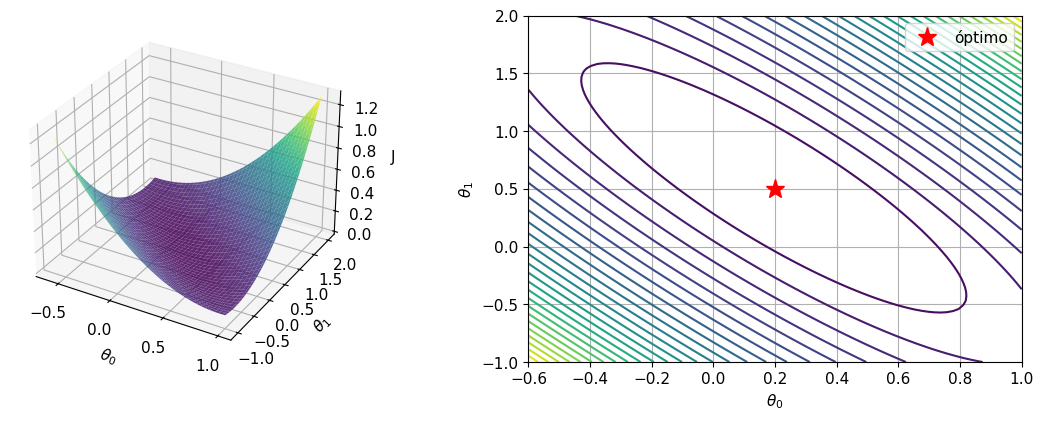

In [16]:
t0g, t1g = np.meshgrid(np.linspace(-0.6, 1.0, 80), np.linspace(-1.0, 2.0, 80))
Jg = np.array([[J(a, b, X, y) for a, b in zip(fa, fb)] for fa, fb in zip(t0g, t1g)])

fig = plt.figure(figsize=(14, 4.5))
ax = fig.add_subplot(121, projection="3d")
ax.plot_surface(t0g, t1g, Jg, cmap="viridis", alpha=0.85)
ax.set_xlabel(r"$	\theta_0$"); ax.set_ylabel(r"$	\theta_1$"); ax.set_zlabel("J")

ax2 = fig.add_subplot(122)
cs = ax2.contour(t0g, t1g, Jg, 30, cmap="viridis")
ax2.plot(*theta_real, "r*", ms=14, label="óptimo")
ax2.set_xlabel(r"$	\theta_0$"); ax2.set_ylabel(r"$	\theta_1$"); ax2.legend()
plt.show()

---
# Parte 2 — Gradiente descendente

Para bajar por la superficie usamos la regla de actualización

$$\theta_j := \theta_j - \alpha\,\frac{\partial J}{\partial \theta_j}$$

donde $\alpha$ es la **tasa de aprendizaje**. Primero, la intuición en 1D con $f(w)=(w-1)^2$, cuyo mínimo está en $w=1$.

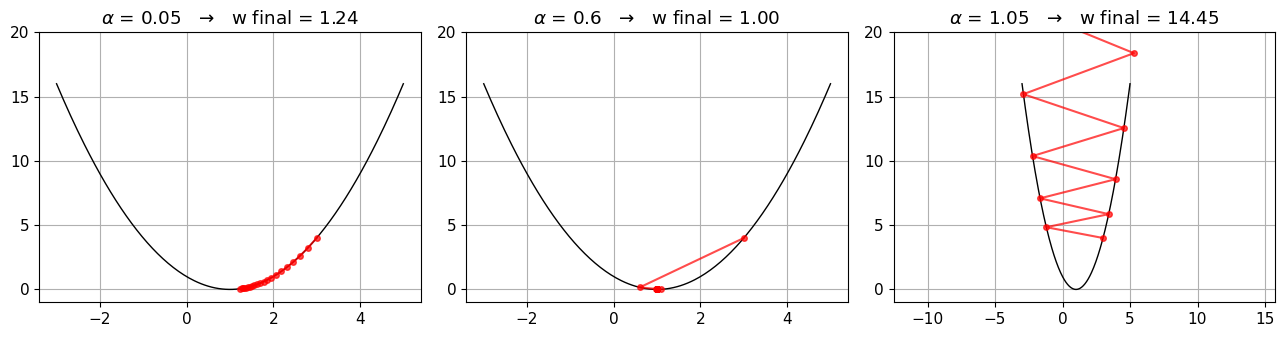

In [20]:
f  = lambda w: (w - 1) ** 2
fp = lambda w: 2 * (w - 1)


def descenso_1d(w0, alpha, n_iter=20):
    w, hist = w0, [w0]
    for _ in range(n_iter):
        w = w - alpha * fp(w)
        hist.append(w)
    return np.array(hist)


w = np.linspace(-3, 5, 200)
plt.figure(figsize=(13, 3.5))
for k, alpha in enumerate([0.05, 0.6, 1.05]):
    hist = descenso_1d(3.0, alpha)
    plt.subplot(1, 3, k + 1)
    plt.plot(w, f(w), "k-", lw=1)
    plt.plot(hist, f(hist), "ro-", ms=4, alpha=0.7)
    plt.title(f"$\\alpha$ = {alpha}   →   w final = {hist[-1]:.2f}")
    plt.ylim(-1, 20)
plt.tight_layout(); plt.show()

Los tres casos resumen todo lo que puede pasar:

* $\alpha$ **muy pequeño**: converge, pero gasta demasiadas iteraciones.
* $\alpha$ **adecuado**: baja rápido y se queda en el mínimo.
* $\alpha$ **muy grande**: sobrepasa el mínimo en cada paso y **diverge**.

Para nuestra función de coste las derivadas parciales son:

$$\frac{\partial J}{\partial\theta_0}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right),
\qquad
\frac{\partial J}{\partial\theta_1}=\frac{1}{m}\sum_{i=1}^{m}\left(h_\theta(x^{(i)})-y^{(i)}\right)x^{(i)}$$

### ✏️ Ejercicio 2.1 — Implemente el gradiente y el descenso

In [37]:
# calculamos el gradiente de J
def grad_J(t0, t1, X, y):
    """Devuelve (dJ/dtheta_0, dJ/dtheta_1)."""
    err = H(X, t0, t1) - y # agumento dentro de la suma
    d0 = np.sum(err) / len(y) # derivada respecto a theta0
    d1 = np.sum(err * X) / len(y) # derivada respecto a theta1
    return d0, d1

# implementación del descenso por gradiente 
def descenso(X, y, alpha, n_iter=3000, t0=0.0, t1=0.0):
    hist = []
    for _ in range(n_iter):
        d0, d1 = grad_J(t0, t1, X, y)
        t0 = t0 - alpha * d0
        t1 = t1 - alpha * d1
        hist.append((t0, t1, J(t0, t1, X, y)))
    return t0, t1, np.array(hist)


t0_gd, t1_gd, hist = descenso(X, y, 0.5)
print(f"theta_0 = {t0_gd:.4f}   theta_1 = {t1_gd:.4f}   (reales: {theta_real})")

theta_0 = 0.1958   theta_1 = 0.5078   (reales: (0.2, 0.5))


In [38]:
# ✅ Checkpoint 2.1 — comparamos contra el ajuste de numpy
p1, p0 = np.polyfit(X, y, 1)
assert abs(t0_gd - p0) < 1e-2 and abs(t1_gd - p1) < 1e-2, "el descenso no llegó al óptimo"
assert hist[-1, 2] < hist[0, 2], "el coste debería disminuir"
print(f"Correcto ✔  (numpy: theta_0={p0:.4f}, theta_1={p1:.4f})")

Correcto ✔  (numpy: theta_0=0.1958, theta_1=0.5078)


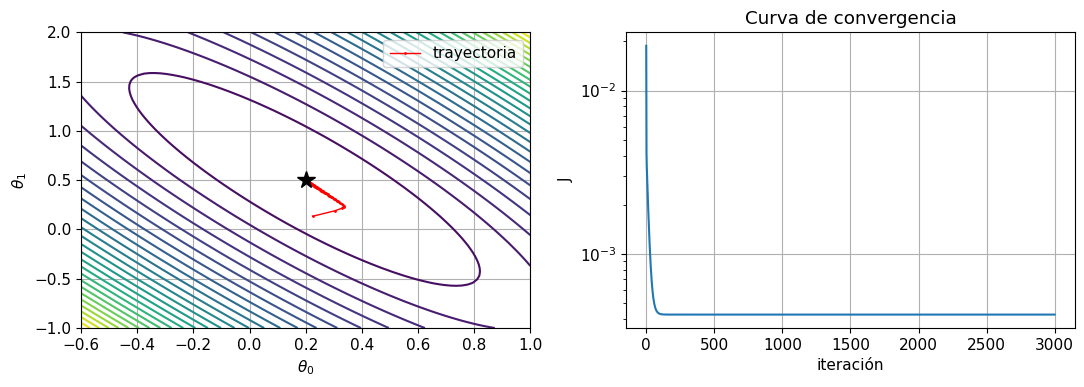

In [39]:
plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.contour(t0g, t1g, Jg, 30, cmap="viridis")
plt.plot(hist[:, 0], hist[:, 1], "r.-", ms=2, lw=1, label="trayectoria")
plt.plot(*theta_real, "k*", ms=13)
plt.xlabel(r"$	\theta_0$"); plt.ylabel(r"$	\theta_1$"); plt.legend()

plt.subplot(122)
plt.semilogy(hist[:, 2])
plt.xlabel("iteración"); plt.ylabel("J"); plt.title("Curva de convergencia")
plt.tight_layout(); plt.show()

**Pregunta guía.** Vuelva a correr `descenso` con `alpha=3.0` y con `alpha=0.01`. ¿Qué observa en la curva de convergencia en cada caso?


Con $\alpha = 0.01 $ se observa el mismo comportamiento que en el caso $1D$, hay convergencia, pero se requieren muchas iteraciones. Con $\alpha = 3.0$ hay una divergencia.

---
# Parte 3 — Regresión multivariada (versión vectorizada)

Con $n$ características, escribimos todo en forma matricial. Añadimos una columna de unos para el intercepto:

$$X=\begin{bmatrix}1 & x_1^{(1)} & \cdots & x_n^{(1)}\\ \vdots & & & \vdots\\ 1 & x_1^{(m)} & \cdots & x_n^{(m)}\end{bmatrix}_{m\times(n+1)},\qquad \Theta=\begin{bmatrix}\theta_0\\ \vdots\\ \theta_n\end{bmatrix}$$

$$h = X\Theta,\qquad J(\Theta)=\frac{1}{2m}\,(h-y)^T(h-y),\qquad \nabla_\Theta J = \frac{1}{m}X^T(h-y)$$

Los bucles de la Parte 2 desaparecen: todo son tres productos matriciales.

In [40]:
def agregar_sesgo(Xf):
    """(m, n) -> (m, n+1) agregando una columna de unos al frente."""
    Xf = np.asarray(Xf, dtype=float)
    if Xf.ndim == 1:
        Xf = Xf.reshape(-1, 1)
    return np.hstack([np.ones((Xf.shape[0], 1)), Xf])


def h_lin(Theta, Xb):
    return Xb @ Theta


def J_lin(Theta, Xb, y):
    r = h_lin(Theta, Xb) - y
    return (r @ r) / (2 * len(y))

### ✏️ Ejercicio 3.1 — El gradiente vectorizado

Traduzca $\nabla_\Theta J = \frac{1}{m}X^T(h-y)$ a una sola línea de numpy.

In [41]:
def grad_lin(Theta, Xb, y):
    m = len(y)
    return (Xb.T @ (Xb @ Theta - y)) / m # el gradiente es ahora simplemente una operación matricial 

# función descenso por gradiente vectoriazado
def descenso_vec(Xb, y, alpha=0.1, n_iter=5000, Theta=None):
    Theta = np.zeros(Xb.shape[1]) if Theta is None else np.array(Theta, dtype=float)
    hist = []
    for _ in range(n_iter):
        Theta = Theta - alpha * grad_lin(Theta, Xb, y)
        hist.append(J_lin(Theta, Xb, y))
    return Theta, np.array(hist)

In [42]:
# ✅ Checkpoint 3.1 — verificación numérica del gradiente
# Comparamos su fórmula contra una derivada numérica: es la mejor forma
# de detectar errores de signo o de transposición.
def grad_numerico(fun, Theta, eps=1e-6):
    g = np.zeros_like(Theta)
    for k in range(len(Theta)):
        e = np.zeros_like(Theta); e[k] = eps
        g[k] = (fun(Theta + e) - fun(Theta - e)) / (2 * eps)
    return g


Xb_test = agregar_sesgo(rng.normal(size=(30, 3)))
y_test = rng.normal(size=30)
Th_test = rng.normal(size=4)

g_ana = grad_lin(Th_test, Xb_test, y_test)
g_num = grad_numerico(lambda T: J_lin(T, Xb_test, y_test), Th_test)
assert np.allclose(g_ana, g_num, atol=1e-6), "el gradiente analítico no coincide con el numérico"
print("Correcto ✔  gradiente analítico == gradiente numérico")

Correcto ✔  gradiente analítico == gradiente numérico


Theta estimado: [-1.0021  0.1951  0.5027]    (real: [-1, 0.2, 0.5])


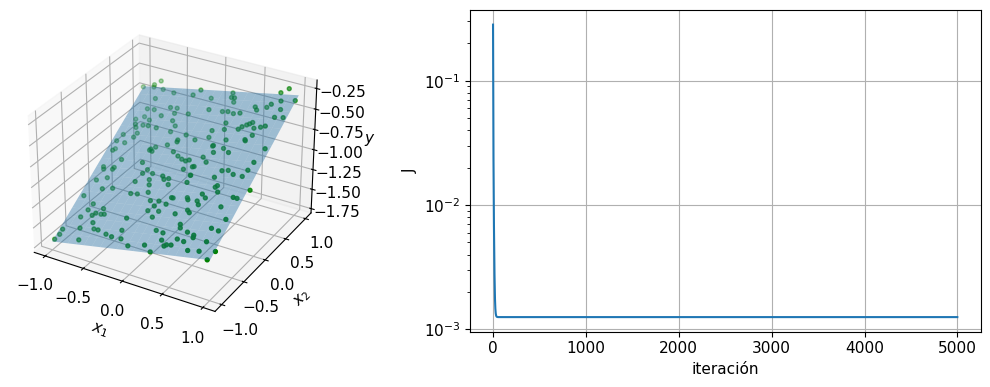

In [43]:
# Datos: un plano  y = -1 + 0.2*x1 + 0.5*x2  con ruido
N = 200
x1 = rng.uniform(-1, 1, N)
x2 = rng.uniform(-1, 1, N)
y2 = -1.0 + 0.2 * x1 + 0.5 * x2 + rng.normal(0, 0.05, N)

Xb = agregar_sesgo(np.column_stack([x1, x2]))
Theta_gd, hist2 = descenso_vec(Xb, y2, alpha=0.3, n_iter=5000)
print("Theta estimado:", np.round(Theta_gd, 4), "   (real: [-1, 0.2, 0.5])")

fig = plt.figure(figsize=(11, 4))
ax = fig.add_subplot(121, projection="3d")
g1, g2 = np.meshgrid(np.linspace(-1, 1, 20), np.linspace(-1, 1, 20))
ax.plot_surface(g1, g2, Theta_gd[0] + Theta_gd[1] * g1 + Theta_gd[2] * g2, alpha=0.4)
ax.scatter(x1, x2, y2, c="g", s=8)
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$"); ax.set_zlabel("$y$")

ax2 = fig.add_subplot(122)
ax2.semilogy(hist2); ax2.set_xlabel("iteración"); ax2.set_ylabel("J")
plt.tight_layout(); plt.show()

---
# Parte 4 — Escalamiento de características

¿Qué pasa si una característica vive en $[-1,1]$ y otra en $[-2000,2000]$? La superficie de coste se vuelve un valle largo y estrecho: el mismo $\alpha$ es demasiado grande en una dirección y demasiado pequeño en la otra.

La solución es **estandarizar**:

$$x_j \leftarrow \frac{x_j-\mu_j}{s_j}$$

con $\mu_j$ la media y $s_j$ la desviación estándar (o el rango) de la característica $j$.

In [44]:
# Sin escalar: x2 tiene un rango 2000 veces mayor que x1
n = 100
z1 = rng.uniform(-1, 1, n)
z2 = rng.uniform(-2000, 2000, n)
yz = 2 * z1 - 3 * z2 + rng.normal(0, 0.1, n)

Xb_mal = agregar_sesgo(np.column_stack([z1, z2]))
with np.errstate(over="ignore", invalid="ignore"):
    _, hist_mal = descenso_vec(Xb_mal, yz, alpha=0.3, n_iter=30)

print("Coste en las 5 primeras iteraciones:", hist_mal[:5])
print("Coste tras 30 iteraciones          :", hist_mal[-1], " ← diverge")
print()
print("Con alpha mucho más pequeño tampoco es buena idea:")
with np.errstate(over="ignore", invalid="ignore"):
    Th_mal, h2 = descenso_vec(Xb_mal, yz, alpha=1e-8, n_iter=2000)
print("  alpha=1e-8, 2000 iteraciones -> Theta =", np.round(Th_mal, 3), " (real: [0, 2, -3])")
print("  el coeficiente de x2 ya está, pero el de x1 ni se ha movido")

Coste en las 5 primeras iteraciones: [1.08591043e+18 1.88635314e+29 3.27681555e+40 5.69221102e+51
 9.88803483e+62]
Coste tras 30 iteraciones          : inf  ← diverge

Con alpha mucho más pequeño tampoco es buena idea:
  alpha=1e-8, 2000 iteraciones -> Theta = [-0. -0. -3.]  (real: [0, 2, -3])
  el coeficiente de x2 ya está, pero el de x1 ni se ha movido


### ✏️ Ejercicio 4.1 — Estandarice y vuelva a entrenar

In [45]:
# función para estandarizar 
def estandarizar(Xf):
    """Devuelve (X escalado, mu, sigma) columna por columna."""
    Xf = np.asarray(Xf, dtype=float)
    mu = np.mean(Xf, axis=0) # media 
    sigma = np.std(Xf, axis=0) # desviación estándar 
    return (Xf - mu) / sigma, mu, sigma


Z = np.column_stack([z1, z2])
Z_esc, mu, sigma = estandarizar(Z)
Xb_bien = agregar_sesgo(Z_esc)
Theta_esc, hist_bien = descenso_vec(Xb_bien, yz, alpha=0.3, n_iter=2000)
print("Coste final tras escalar:", round(hist_bien[-1], 4))

Coste final tras escalar: 0.0049


In [46]:
# ✅ Checkpoint 4.1
assert np.allclose(Z_esc.mean(axis=0), 0, atol=1e-10), "la media escalada debe ser 0"
assert np.allclose(Z_esc.std(axis=0), 1, atol=1e-10), "la desviación escalada debe ser 1"
assert np.isfinite(hist_bien[-1]) and hist_bien[-1] < 10, "el descenso aún no converge"
print("Correcto ✔")

# Los parámetros escalados se devuelven al espacio original así:
t_orig = Theta_esc[1:] / sigma
t0_orig = Theta_esc[0] - (Theta_esc[1:] * mu / sigma).sum()
print("Coeficientes en unidades originales:", np.round([t0_orig, *t_orig], 3), " (real: [0, 2, -3])")

Correcto ✔
Coeficientes en unidades originales: [-0.008  1.971 -3.   ]  (real: [0, 2, -3])


---
# Parte 5 — La ecuación normal

Para el error cuadrático **no hace falta iterar**: el mínimo tiene solución cerrada. Partiendo de

$$J(\Theta)=\frac{1}{2m}(X\Theta-y)^T(X\Theta-y),\qquad \nabla_\Theta J=\frac{1}{m}\left(X^TX\,\Theta-X^Ty\right)$$

e imponiendo $\nabla_\Theta J = 0$:

$$\boxed{\;\Theta=(X^TX)^{-1}X^Ty\;}$$

*(La demostración completa queda como tarea; use $\nabla_x b^Tx=b$ y $\nabla_x x^TAx=2Ax$ con $A$ simétrica.)*

**Nota práctica:** nunca invierta la matriz explícitamente. `np.linalg.solve(A, b)` resuelve $A\Theta=b$ y es más estable y rápido que `np.linalg.inv(A) @ b`.

### ✏️ Ejercicio 5.1 — Implemente la ecuación normal

In [47]:
def ecuacion_normal(Xb, y):
    """Theta = (X^T X)^{-1} X^T y, resuelto con np.linalg.solve."""
    A = Xb.T @ Xb
    b = Xb.T @ y
    return np.linalg.solve(A, b)


Theta_ne = ecuacion_normal(Xb, y2)
print("Ecuación normal   :", np.round(Theta_ne, 4))
print("Gradiente desc.   :", np.round(Theta_gd, 4))

Ecuación normal   : [-1.0021  0.1951  0.5027]
Gradiente desc.   : [-1.0021  0.1951  0.5027]


In [48]:
# ✅ Checkpoint 5.1
assert np.allclose(Theta_ne, Theta_gd, atol=1e-3), "los dos métodos deberían coincidir"
assert J_lin(Theta_ne, Xb, y2) <= J_lin(Theta_gd, Xb, y2) + 1e-9, "la solución cerrada es la óptima"
print("Correcto ✔  ambos métodos llegan al mismo mínimo")

Correcto ✔  ambos métodos llegan al mismo mínimo


In [49]:
# Datos reales: diabetes (442 pacientes, 10 características)
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression

datos = load_diabetes()
Xd, yd = datos.data, datos.target
Xdb = agregar_sesgo(Xd)

Theta_d = ecuacion_normal(Xdb, yd)
skl = LinearRegression().fit(Xd, yd)

print("Nuestro intercepto :", round(Theta_d[0], 4), "  sklearn:", round(skl.intercept_, 4))
print("Máxima diferencia en los coeficientes:", np.abs(Theta_d[1:] - skl.coef_).max())

r2 = 1 - ((Xdb @ Theta_d - yd) ** 2).sum() / ((yd - yd.mean()) ** 2).sum()
print("R^2 =", round(r2, 4))

Nuestro intercepto : 152.1335   sklearn: 152.1335
Máxima diferencia en los coeficientes: 3.0127011996228248e-12
R^2 = 0.5177


### ¿Gradiente descendente o ecuación normal?

| | Gradiente descendente | Ecuación normal |
|---|---|---|
| Hiperparámetros | requiere elegir $\alpha$ y n.º de iteraciones | ninguno |
| Escalamiento | imprescindible | innecesario |
| Costo | $O(k\,n^2)$ | $O(n^3)$ por la inversión |
| $n$ grande ($>10^4$) | funciona bien | se vuelve inviable |
| Otros modelos | sirve para logística, redes, etc. | solo mínimos cuadrados |

### ¿Por qué mínimos cuadrados y no otra métrica?

Si suponemos $y^{(i)}=\Theta^TX^{(i)}+\epsilon_i$ con $\epsilon_i\sim\mathcal{N}(0,\sigma^2)$ i.i.d., la verosimilitud es

$$\mathcal{L}(\Theta)=\prod_{i=1}^{m}\frac{1}{\sqrt{2\pi}\sigma}e^{-\frac{(y^{(i)}-\Theta^TX^{(i)})^2}{2\sigma^2}}
\;\Longrightarrow\;
\ell(\Theta)=\text{cte}-\frac{1}{2\sigma^2}\sum_{i=1}^{m}\left(y^{(i)}-\Theta^TX^{(i)}\right)^2$$

Maximizar $\ell$ es **exactamente** minimizar el error cuadrático. Los mínimos cuadrados son el estimador de máxima verosimilitud bajo ruido gaussiano; si el ruido no es gaussiano, otra métrica puede ser mejor.

---
# Parte 6 — Clasificación: regresión logística

Ahora $y\in\{0,1\}$. Queremos que la salida sea una **probabilidad**, así que pasamos $\Theta^TX$ por la sigmoide:

$$h_\Theta(X)=\sigma(\Theta^TX)=\frac{1}{1+e^{-\Theta^TX}}=P(y=1\mid X;\Theta),
\qquad \sigma'(z)=\sigma(z)\,(1-\sigma(z))$$

La regla de decisión es simplemente el signo del argumento:

* $\Theta^TX \ge 0 \Rightarrow h \ge 0.5 \Rightarrow$ clase 1
* $\Theta^TX < 0 \Rightarrow h < 0.5 \Rightarrow$ clase 0

La ecuación $\Theta^TX = 0$ define la **frontera de decisión**.

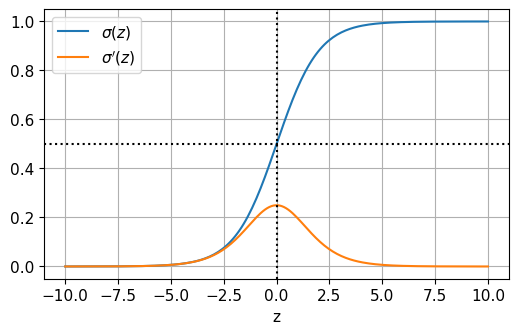

In [50]:
sigmoide = lambda z: 1 / (1 + np.exp(-z))
z = np.linspace(-10, 10, 200)

plt.figure(figsize=(6, 3.5))
plt.plot(z, sigmoide(z), label=r"$\sigma(z)$")
plt.plot(z, sigmoide(z) * (1 - sigmoide(z)), label=r"$\sigma'(z)$")
plt.axhline(0.5, color="k", ls=":"); plt.axvline(0, color="k", ls=":")
plt.xlabel("z"); plt.legend(); plt.show()

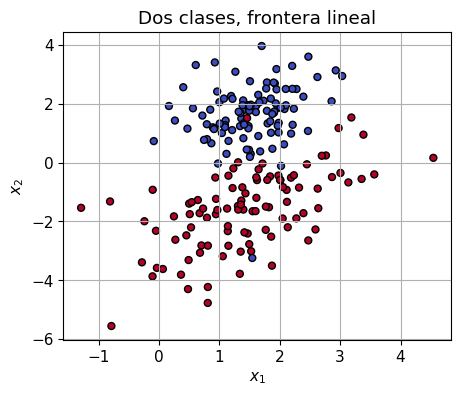

In [51]:
from sklearn.datasets import make_classification, make_circles

Xc, yc = make_classification(n_samples=200, n_features=2, n_redundant=0,
                             n_informative=2, n_clusters_per_class=1,
                             class_sep=1.5, random_state=1)

plt.figure(figsize=(5, 4))
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=25)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Dos clases, frontera lineal")
plt.show()

### Fronteras no lineales

Nada obliga a que $\Theta^TX$ sea lineal en las características originales. Si agregamos términos polinómicos, por ejemplo

$$\theta_0+\theta_1x_1+\theta_2x_2+\theta_3x_1^2+\theta_4x_2^2 \ge 0,$$

la frontera puede ser una circunferencia, una elipse, etc.

### ✏️ Ejercicio 6.1 — Encuentre la frontera circular

Para los datos de `make_circles`, con $\Theta=[-r^2,\,0,\,0,\,1,\,1]$ la frontera es $x_1^2+x_2^2=r^2$. Busque el radio $r$ que mejor separa las clases.

In [52]:
Xr, yr = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=0)
# En make_circles la clase 1 es el círculo interior.

def clasifica_circulo(Xf, r):
    """Devuelve 1 si el punto está dentro del círculo de radio r."""
    return (Xf[:, 0]**2 + Xf[:, 1]**2) < r**2


radios = np.linspace(0.2, 1.0, 100)
exactitudes = np.array([(clasifica_circulo(Xr, r) == yr).mean() for r in radios])
r_opt = radios[np.argmax(exactitudes)]
print(f"Radio óptimo = {r_opt:.3f}   exactitud = {exactitudes.max():.3f}")

Radio óptimo = 0.636   exactitud = 1.000


Correcto ✔


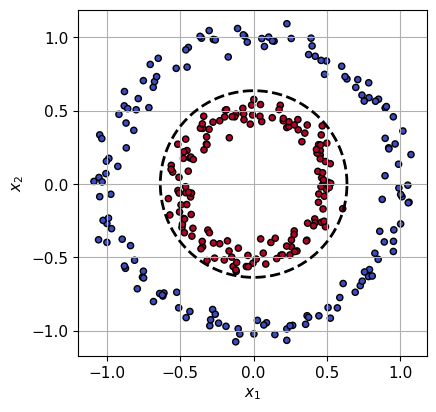

In [53]:
# ✅ Checkpoint 6.1
assert exactitudes.max() > 0.95, "debería poder separar los anillos casi perfectamente"
print("Correcto ✔")

ang = np.linspace(0, 2 * np.pi, 200)
plt.figure(figsize=(4.5, 4.5))
plt.scatter(Xr[:, 0], Xr[:, 1], c=yr, cmap="coolwarm", edgecolor="k", s=20)
plt.plot(r_opt * np.cos(ang), r_opt * np.sin(ang), "k--", lw=2)
plt.axis("equal"); plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.show()

### Función de coste: entropía cruzada

El error cuadrático no sirve aquí (produce una superficie con múltiples mínimos locales). Se usa

$$J(\Theta)=-\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log h_\Theta(X^{(i)})+(1-y^{(i)})\log\left(1-h_\Theta(X^{(i)})\right)\right]$$

que penaliza fuertemente predecir con confianza la clase equivocada. Y aquí está el resultado elegante del laboratorio: su gradiente es

$$\nabla_\Theta J=\frac{1}{m}X^T\left(h_\Theta(X)-y\right)$$

**idéntico en forma al de la regresión lineal**; lo único que cambia es la definición de $h$. (Sale de $\sigma'=\sigma(1-\sigma)$ y de la regla de la cadena.)

### ✏️ Ejercicio 6.2 — Entrene un clasificador desde cero

In [55]:
def h_log(Theta, Xb):
    return sigmoide(Xb @ Theta)


def J_log(Theta, Xb, y, eps=1e-12):
    p = h_log(Theta, Xb)
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))


def grad_log(Theta, Xb, y):
    m = len(y)
    return (Xb.T @ (h_log(Theta, Xb) - y)) / m


def descenso_log(Xb, y, alpha=0.5, n_iter=5000):
    Theta, hist = np.zeros(Xb.shape[1]), []
    for _ in range(n_iter):
        Theta = Theta - alpha * grad_log(Theta, Xb, y)
        hist.append(J_log(Theta, Xb, y))
    return Theta, np.array(hist)


Xcb = agregar_sesgo(Xc)
Theta_log, hist_log = descenso_log(Xcb, yc)
pred = (h_log(Theta_log, Xcb) >= 0.5).astype(int)
acc_propio = (pred == yc).mean()
print("Theta:", np.round(Theta_log, 3), "  exactitud:", round(acc_propio, 3))

Theta: [-1.762  1.46  -2.797]   exactitud: 0.975


In [56]:
# ✅ Checkpoint 6.2 — contra sklearn y contra el gradiente numérico
from sklearn.linear_model import LogisticRegression

g_ana = grad_log(np.array([0.3, -0.2, 0.5]), Xcb, yc)
g_num = grad_numerico(lambda T: J_log(T, Xcb, yc), np.array([0.3, -0.2, 0.5]))
assert np.allclose(g_ana, g_num, atol=1e-6), "revise grad_log"

ref = LogisticRegression(C=1e6, max_iter=5000).fit(Xc, yc)
assert abs(acc_propio - ref.score(Xc, yc)) < 0.05, "exactitud lejos de la de sklearn"
print(f"Correcto ✔  sklearn: {ref.score(Xc, yc):.3f}   nuestro: {acc_propio:.3f}")

Correcto ✔  sklearn: 0.975   nuestro: 0.975


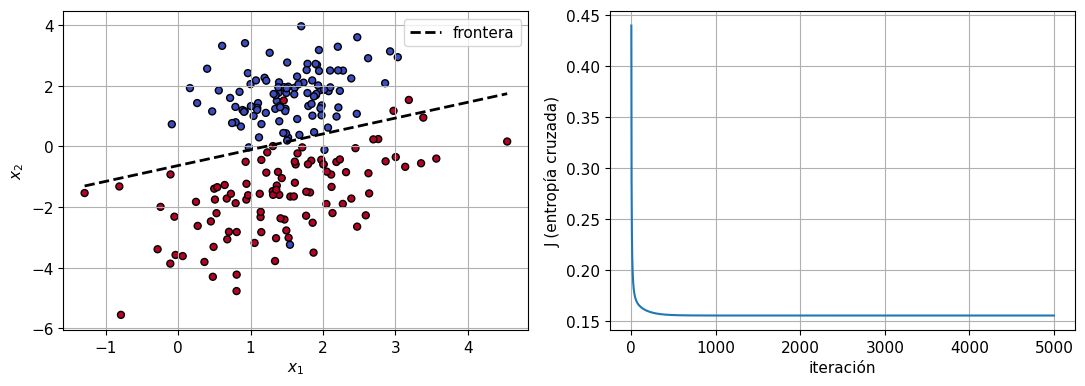

In [57]:
# Frontera de decisión:  theta_0 + theta_1 x1 + theta_2 x2 = 0
xx = np.linspace(Xc[:, 0].min(), Xc[:, 0].max(), 50)
yy = -(Theta_log[0] + Theta_log[1] * xx) / Theta_log[2]

plt.figure(figsize=(11, 4))
plt.subplot(121)
plt.scatter(Xc[:, 0], Xc[:, 1], c=yc, cmap="coolwarm", edgecolor="k", s=25)
plt.plot(xx, yy, "k--", lw=2, label="frontera")
plt.ylim(Xc[:, 1].min() - 0.5, Xc[:, 1].max() + 0.5)
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.legend()

plt.subplot(122)
plt.plot(hist_log); plt.xlabel("iteración"); plt.ylabel("J (entropía cruzada)")
plt.tight_layout(); plt.show()

---
# Parte 7 — Multiclase y regularización

**Multiclase.** Con $K>2$ clases hay dos estrategias:

* *Uno contra todos*: se entrenan $K$ clasificadores binarios (clase $k$ vs. el resto) y se elige el de mayor probabilidad.
* *Softmax*: se generaliza la sigmoide a $P(y=k\mid X)=\dfrac{e^{\Theta_k^TX}}{\sum_j e^{\Theta_j^TX}}$ y se entrena un solo modelo.

**Regularización.** Para controlar el sobreajuste se penalizan los parámetros grandes:

$$J_{reg}(\Theta)=J(\Theta)+\frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2
\qquad\Longrightarrow\qquad
\theta_j := \theta_j\left(1-\alpha\frac{\lambda}{m}\right)-\frac{\alpha}{m}\sum_{i=1}^{m}\left(h_\Theta(X^{(i)})-y^{(i)}\right)x_j^{(i)}$$

El intercepto $\theta_0$ **no** se regulariza. En `scikit-learn` el parámetro es `C` $=1/\lambda$: **C pequeño = mucha regularización**.

In [58]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

iris = load_iris()
Xi, yi = iris.data, iris.target
Xtr, Xte, ytr, yte = train_test_split(Xi, yi, test_size=0.3, stratify=yi, random_state=42)

modelo = make_pipeline(StandardScaler(), LogisticRegression(C=1.0, max_iter=1000))
modelo.fit(Xtr, ytr)
print("Exactitud entrenamiento:", round(modelo.score(Xtr, ytr), 3))
print("Exactitud prueba       :", round(modelo.score(Xte, yte), 3))

flor = np.array([[5.9, 3.0, 5.1, 1.8]])
p = modelo.predict_proba(flor)[0]
for nombre, prob in zip(iris.target_names, p):
    print(f"  P({nombre:<12}) = {prob:.3f}")

Exactitud entrenamiento: 0.981
Exactitud prueba       : 0.911
  P(setosa      ) = 0.005
  P(versicolor  ) = 0.341
  P(virginica   ) = 0.653


### ✏️ Ejercicio 7.1 — El efecto de la regularización

Barra `C` en escala logarítmica y grafique la exactitud en entrenamiento y en prueba.

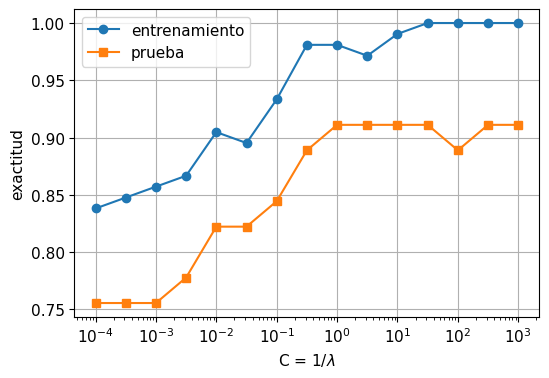

In [59]:
Cs = np.logspace(-4, 3, 15)
acc_tr, acc_te = [], []

for c in Cs:
    m_ = make_pipeline(StandardScaler(), LogisticRegression(C=c, max_iter=1000))
    m_.fit(Xtr, ytr)
    acc_tr.append(m_.score(Xtr, ytr))   # TODO: exactitud en entrenamiento
    acc_te.append(m_.score(Xte, yte))   # TODO: exactitud en prueba

plt.figure(figsize=(6, 4))
plt.semilogx(Cs, acc_tr, "o-", label="entrenamiento")
plt.semilogx(Cs, acc_te, "s-", label="prueba")
plt.xlabel("C = 1/$\\lambda$"); plt.ylabel("exactitud"); plt.legend(); plt.show()

In [60]:
# ✅ Checkpoint 7.1
assert len(acc_tr) == len(Cs) and len(acc_te) == len(Cs), "faltan valores en el barrido"
assert acc_tr[0] < acc_tr[-1], "con C muy pequeño el modelo debe quedar subajustado"
print(f"Correcto ✔  mejor C = {Cs[int(np.argmax(acc_te))]:.4g}  "
      f"(exactitud de prueba {max(acc_te):.3f})")

Correcto ✔  mejor C = 1  (exactitud de prueba 0.911)



## Preguntas de análisis (para el informe)

1. ¿Por qué el error cuadrático produce una superficie de coste convexa mientras que aplicado a la sigmoide no lo hace?

En el caso de regresión lineal, vimos en el taller teórico que la función de coste, y en particular su gradiente tiene la sigueinte forma:

$$ \nabla_{\theta} J(\theta) = \frac{1}{2 m} (X^T X \Theta - X^T \vec{y})$$

Y por tanto, su segunda derivada, la matriz Hessiana es


$$ H = \nabla_{\theta} J(\theta)  \frac{1}{2 m} X^T X  $$

Para cualquier vector $v$, podemos calcular 

$$ v^T H v = \frac{1}{2m} v^T (X^T X) v = \frac{1}{2 m} (Xv)^T (X v) = || X v ||^2 \geq 0 $$

Dada la última igualdad, la matriz H es semidefinida positiva. Esto sinigica que la superficie definida por la función de coste es convexa con un solo mínimo global.

En el caso de la función sigmoide, el error cuadrático es 

$$ J(\theta) = \frac{1}{2 m} (\sigma (\theta x) - X^T \vec{y})^2$$

Dada la dependencia no lineal, y las regiones de saturación que presenta la función sigmoide, la matriz Hessiana no necesariamente es definida positiva. Puede tener mínimos locales o regiones planas. 

2. Usted entrena con $\alpha=0.01$ durante 100 iteraciones y el coste baja muy poco. Enumere dos causas posibles y cómo distinguirlas.

 La primera causa puede ser que la tasa de aprendizaje es muy pequeńa. Se podría aumentar por ejemplo a 0.1 y observar si el coste empieza a disminuir más rápido. 

 En segundo lugar, puede ser que las características no estén escaladas adecuadamente. Sin aplicar normalización, la superficie de la función de costo puede ser muy grande y el descenso por gradiente puede avanzar de forma ineficiente. Se puede estandarizar y volver a entrenar para ver si hay alguna mejora. 


3. Con $n=50\,000$ características, ¿usaría la ecuación normal? Justifique con la tabla de la Parte 5.

No es viable usar la ecuación normal en este caso dado su coste de $O(3)$. La ecuación normal requeriría invertir una matriz de tamaño $50 000 \times 50 0000$.

4. En la gráfica del Ejercicio 7.1, ¿qué región corresponde a subajuste y cuál a sobreajuste? ¿Qué valor de $C$ reportaría y por qué?

La zona de subajuste se encuentra en las regiones de  valores pequeños de C: $(10^{-4}, 10^{-2})$, lo que corresponde a un valor alto de regularización . En este caso, tanto el training como el test tienen una exactitud baja $(80 \% - 90 \%)$.

La zona de sobreajuste corresponde a valores altos de C, principalmente en el rango $(10^1, 10^3)$, lo que se corresponde con una regualarización muy pequeña. El modelo alcanza $100 \%$ de precisión con los datos de entrenamiento, pero no es capaz de predecir con exactitud los datos de prueba, es decir, el modelo está memorizando los datos de entrenamiento. 

El valor $C = 10^0 = 1$ parece un valor óptimo , pues es donde los datos de prueba alcanzan su máximo pico con la menor complejidad posible, antes que el entrenamiento llegue al $100 \%$ y haga sobreajuste.



## Retos opcionales

* **A. Otras métricas.** Generalice el coste a $J=\frac{1}{pm}\sum_i (h_\theta(x^{(i)})-y^{(i)})^p$. Compare los $\Theta$ obtenidos con $p=1,2,3$ sobre los datos de la Parte 1 y explique cuál es más robusto a valores atípicos (agregue algunos y compruébelo).
* **B. Curvas de aprendizaje.** Grafique $J_{train}$ y $J_{test}$ en función del tamaño del conjunto de entrenamiento para el modelo de la Parte 5. ¿Qué diagnóstico sugieren?
* **C. Clasificación de púlsares.** Con el dataset [HTRU2](https://archive.ics.uci.edu/ml/datasets/HTRU2), construya un clasificador logístico: divida en train/test, entrene, analice las curvas de aprendizaje y aplique regularización. Discuta por qué la exactitud es una métrica engañosa en un dataset tan desbalanceado.

## Referencias

1. Stanford CS229 — <http://cs229.stanford.edu/syllabus.html>
2. A. Ng, *Machine Learning* (Coursera), semanas 1–3.
3. A. Géron, *Hands-On Machine Learning*, cap. 4.
4. Documentación de scikit-learn — <https://scikit-learn.org/stable/>